Random Forest Model with 23 features being used to predict next day closing price

Importing all the necessary Libraries 

In [1]:
#Standard library
import os
import random
from datetime import datetime

#Data manipulation
import numpy as np
import pandas as pd

#Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#Machine learning
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

#Financial data
import yfinance as yf

Removing randomness from the model to enforce consistent results

In [2]:
#Ensures hash-based operations (like in dicts, sets, or some internal functions) are reproducible across runs
os.environ['PYTHONHASHSEED'] = '0'  # For hash-based operations

#Makes Python’s built-in random module deterministic.
random.seed(42)

#Makes NumPy random operations deterministic (used by scikit-learn, pandas sampling, etc.).
np.random.seed(42)

Code to fetch and download data (Apple Stock Price) from Yahoo everyday roughly for the past 10 years 

In [3]:
#Downloading historical stock data from Apple for the pat 10 years
#The resulting data is a datframe with columns [Open, High, Low, Close, Volume] with the index being the date of each trading day.

ticker = 'AAPL'  
data = yf.download(ticker, start="2015-01-01", end="2025-12-26")

#moving date from the index into a regular column - this allows you to extract the dates
data.reset_index(inplace=True)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').reset_index(drop=True)

#Creating Lag features
lags = [1, 2, 5, 10]

for lag in lags:
    data[f'Close_t-{lag}'] = data['Close'].shift(lag)

#Creating a Return feature - computing the percentage change from yestredays day
data['Return_t-1'] = data['Close'].pct_change(1)
data['Return_t-2'] = data['Close'].pct_change(2)
data['Return_t-5'] = data['Close'].pct_change(5)

#Rolling returns
data['Rolling_Return_5'] = data['Return_t-1'].rolling(5).mean()
data['Rolling_Return_10'] = data['Return_t-1'].rolling(10).mean()

#Moving Averages features
data['MA_10'] = data['Close'].rolling(window=10).mean() #10 day moving average
data['MA_50'] = data['Close'].rolling(window=50).mean() #50 day moving average

#Relative distance features 
data['Close_to_MA10'] = (data['Close'] - data['MA_10']) / data['MA_10']
data['Close_to_MA50'] = (data['Close'] - data['MA_50']) / data['MA_50']
data['MA10_to_MA50'] = (data['MA_10'] - data['MA_50']) / data['MA_50']

#Volatility features
data['Volatility_5'] = data['Return_t-1'].rolling(window=5).std()
data['Volatility_20'] = data['Return_t-1'].rolling(window=20).std()
data['Volatility_Ratio'] = data['Volatility_5'] / data['Volatility_20']

#Volume features
data['Volume_t-1'] = data['Volume'].shift(1)
data['Volume_MA10'] = data['Volume'].rolling(window=10).mean()
data['Volume_MA20'] = data['Volume'].rolling(window=20).mean()

data['Volume_Change'] = (data['Volume'] - data['Volume_MA10']) / data['Volume_MA10']
data['Volume_Spike'] = data['Volume'] / data['Volume_MA20']


#RSI (Relative Strength Index) - a momentum indicator showing whether a stock is overbought or oversold
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

data['RSI'] = compute_rsi(data['Close'])

#Tree-friendly binary signals
data['RSI_Overbought'] = (data['RSI'] > 70).astype(int)
data['RSI_Oversold'] = (data['RSI'] < 30).astype(int)

#Target: next day's closing price
data['Target'] = data['Close'].shift(-1)

#Remove any NaN values from the dataset
data = data.dropna().reset_index(drop=True)

features = [ 'Close_t-1', 'Close_t-2', 'Close_t-5', 'Close_t-10',
    'Return_t-1', 'Return_t-2', 'Return_t-5',
    'Rolling_Return_5', 'Rolling_Return_10',
    'MA_10', 'MA_50',
    'Close_to_MA10', 'Close_to_MA50', 'MA10_to_MA50',
    'Volatility_5', 'Volatility_20', 'Volatility_Ratio',
    'Volume_t-1', 'Volume_Change', 'Volume_Spike',
    'RSI', 'RSI_Overbought', 'RSI_Oversold'] 

X = data[features]
y = data['Target']

C:\Users\Sxk1332\AppData\Local\Temp\ipykernel_11628\3411306311.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2025-12-26")
[*********************100%***********************]  1 of 1 completed


In [4]:
print("Dataset shape:")
print("X:", X.shape)
print("y:", y.shape)


Dataset shape:
X: (2712, 23)
y: (2712,)


Splitting the data into a training set (first 85%) and testing set (remaining 15%)

In [5]:
total_size = len(data)

#Taking the first 85% of the data as training and the remaining 15% is testing - preserving the chronological order
train_size = int(total_size * 0.85)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print(f"Total dataset size: {total_size}")
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Train + Test = {len(X_train) + len(X_test)}")


Total dataset size: 2712
Train size: 2305 | Test size: 407
Train + Test = 2712


Tree-based models do not require feature normalization due to their threshold-based splitting mechanism. therefore, raw OHLCV values were used.

Building and Training the model

In [6]:
rf_model = RandomForestRegressor(
    n_estimators=300,  #Number of trees in the forest, usually more trees = better performance but slower
    max_depth= 10,#Maximum depth of each tree. Limits overfitting, smaller = simpler tree. Larger = more complex tree
    min_samples_leaf=5, #Minimum number of samples required to be in a leaf node. Helps reduce overfitting
    bootstrap=True,
    max_features='sqrt', 
    random_state=42, #Seed for random number generator. Ensures reproducibility 
    n_jobs=-1 #Number of CPU cores to use. -1 ensures all cores are being used - fastest training
)

rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Predictions

In [7]:
rf_predictions = rf_model.predict(X_test)

#Calculate metrics on unscaled data

#RMSE (Root Mean Squared Error): Average prediction error, penalizes large errors more
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

#MAE (Mean Absolute Error): Average absolute difference between predicted and actual prices
mae = mean_absolute_error(y_test, rf_predictions)

print(f"\nUnscaled Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Unscaled Mean Absolute Error (MAE): ${mae:.2f}")


Unscaled Root Mean Squared Error (RMSE): $46.24
Unscaled Mean Absolute Error (MAE): $40.82


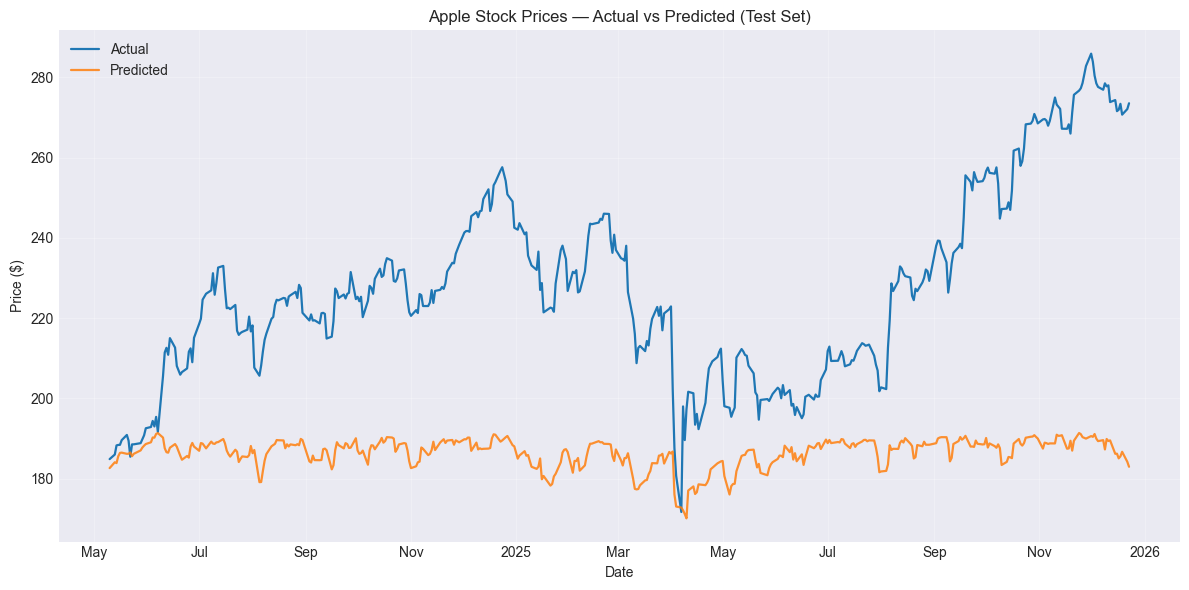

In [8]:
dates_test = data['Date'][-len(rf_predictions):].values

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 6))

plt.plot(dates_test, y_test.values, label="Actual", linewidth=1.6)
plt.plot(dates_test, rf_predictions, label="Predicted", linewidth=1.6, alpha=0.85)

plt.title("Apple Stock Prices — Actual vs Predicted (Test Set)")
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.legend()

# Format x-axis dates nicely
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()